In [1]:
import numpy as np
from matplotlib import pyplot as plt

from engine import Chain, ModulatedPanner, Panner, SineOscillator

## Example 1: Static Panning

Let's create a simple tone and pan it to different positions

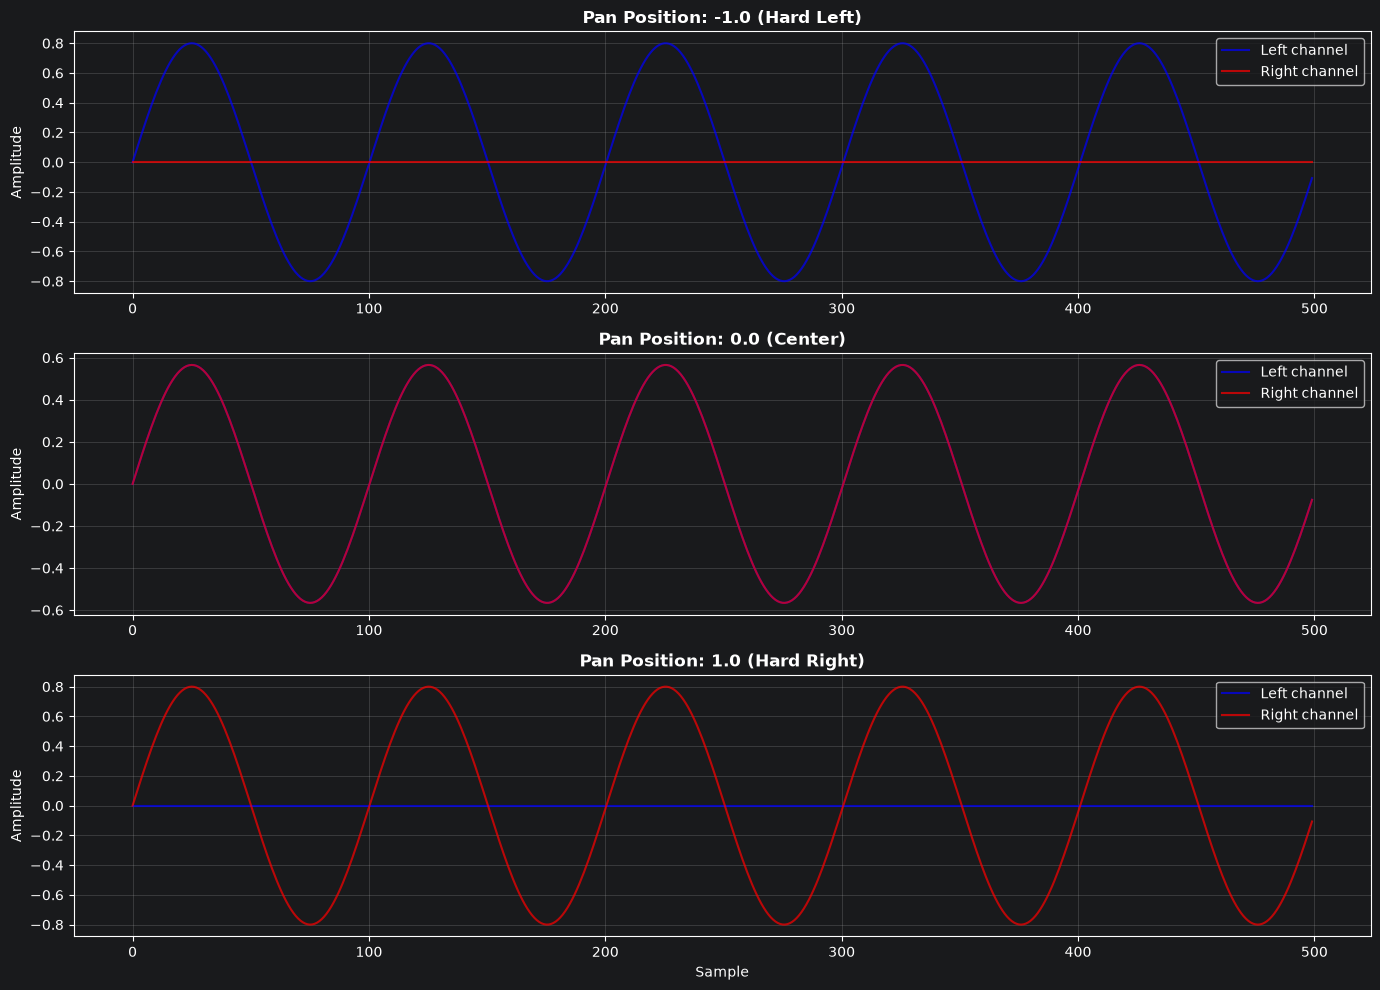

Pan Position Guide:
  -1.0 = Full Left (only left speaker)
   0.0 = Center (both speakers equally)
   1.0 = Full Right (only right speaker)


In [2]:
# Create a 440Hz sine wave (A4 note)
osc = SineOscillator(440, amplitude=0.8)

# Create panners at different positions
panner_left = Panner(-1.0)  # Full left
panner_center = Panner(0.0)  # Center
panner_right = Panner(1.0)  # Full right

# Generate a short burst of audio
samples_mono = osc.get_samples(500)

# Apply different pan positions
left_l, left_r = panner_left(samples_mono)
center_l, center_r = panner_center(samples_mono)
right_l, right_r = panner_right(samples_mono)

# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Hard left
axes[0].plot(left_l, "b-", label="Left channel", alpha=0.7, linewidth=1.5)
axes[0].plot(left_r, "r-", label="Right channel", alpha=0.7, linewidth=1.5)
axes[0].set_title("Pan Position: -1.0 (Hard Left)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Center
axes[1].plot(center_l, "b-", label="Left channel", alpha=0.7, linewidth=1.5)
axes[1].plot(center_r, "r-", label="Right channel", alpha=0.7, linewidth=1.5)
axes[1].set_title("Pan Position: 0.0 (Center)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Amplitude")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# Hard right
axes[2].plot(right_l, "b-", label="Left channel", alpha=0.7, linewidth=1.5)
axes[2].plot(right_r, "r-", label="Right channel", alpha=0.7, linewidth=1.5)
axes[2].set_title("Pan Position: 1.0 (Hard Right)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Sample")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Pan Position Guide:")
print("  -1.0 = Full Left (only left speaker)")
print("   0.0 = Center (both speakers equally)")
print("   1.0 = Full Right (only right speaker)")

## Example 2: Understanding wave_range

The `wave_range` parameter controls the output range of oscillators.
By default, oscillators output values in the range [-1, 1].


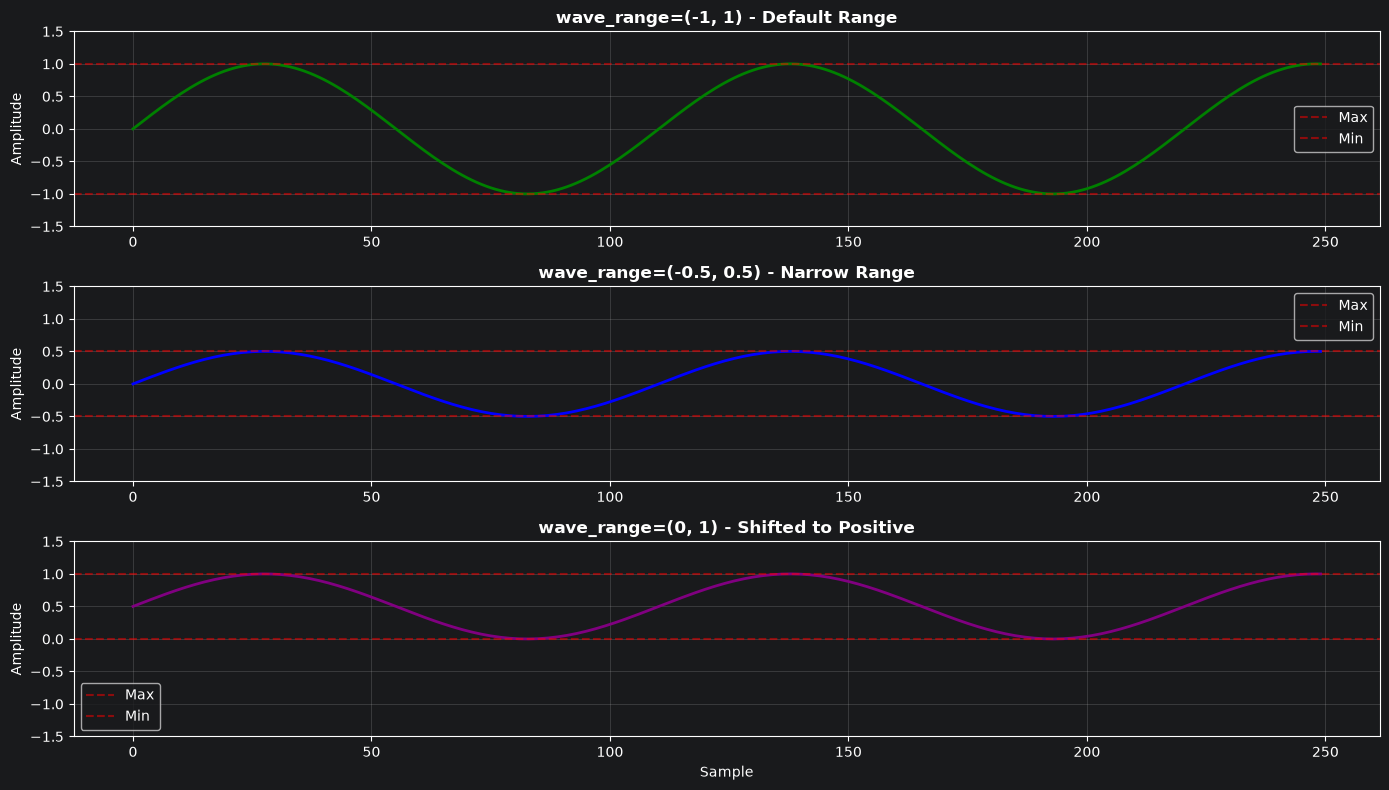


wave_range Parameter:
  Controls the minimum and maximum output values
  Default: (-1, 1) for full range
  Use (-0.8, 0.8) to limit the range slightly
  Use (0, 1) to shift output to positive only


In [3]:
osc_default = SineOscillator(400, amplitude=1.0, wave_range=(-1, 1))  # Default
osc_narrow = SineOscillator(400, amplitude=1.0, wave_range=(-0.5, 0.5))  # Narrow
osc_shifted = SineOscillator(
    400, amplitude=1.0, wave_range=(0, 1)
)  # Shifted to positive

# Generate samples
samples_default = osc_default.get_samples(250)
samples_narrow = osc_narrow.get_samples(250)
samples_shifted = osc_shifted.get_samples(250)

# Plot
plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(samples_default, "g-", linewidth=2)
plt.axhline(y=1, color="r", linestyle="--", alpha=0.5, label="Max")
plt.axhline(y=-1, color="r", linestyle="--", alpha=0.5, label="Min")
plt.title("wave_range=(-1, 1) - Default Range", fontsize=12, fontweight="bold")
plt.ylabel("Amplitude")
plt.ylim(-1.5, 1.5)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(samples_narrow, "b-", linewidth=2)
plt.axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="Max")
plt.axhline(y=-0.5, color="r", linestyle="--", alpha=0.5, label="Min")
plt.title("wave_range=(-0.5, 0.5) - Narrow Range", fontsize=12, fontweight="bold")
plt.ylabel("Amplitude")
plt.ylim(-1.5, 1.5)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(samples_shifted, "purple", linewidth=2)
plt.axhline(y=1, color="r", linestyle="--", alpha=0.5, label="Max")
plt.axhline(y=0, color="r", linestyle="--", alpha=0.5, label="Min")
plt.title("wave_range=(0, 1) - Shifted to Positive", fontsize=12, fontweight="bold")
plt.ylabel("Amplitude")
plt.xlabel("Sample")
plt.ylim(-1.5, 1.5)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\nwave_range Parameter:")
print("  Controls the minimum and maximum output values")
print("  Default: (-1, 1) for full range")
print("  Use (-0.8, 0.8) to limit the range slightly")
print("  Use (0, 1) to shift output to positive only")

## Example 3: Auto-Panning with wave_range

Now let's use an oscillator with wave_range to control panning.
The wave_range limits how far left/right the panning goes.

**How it works:**
- The LFO (Low Frequency Oscillator) generates control values
- wave_range=(-1, 1) means the LFO outputs values from -1 to 1
- ModulatedPanner maps these values to pan positions
- So wave_range=(-1, 1) creates full left-to-right panning
- And wave_range=(-0.5, 0.5) creates limited panning (more centered)


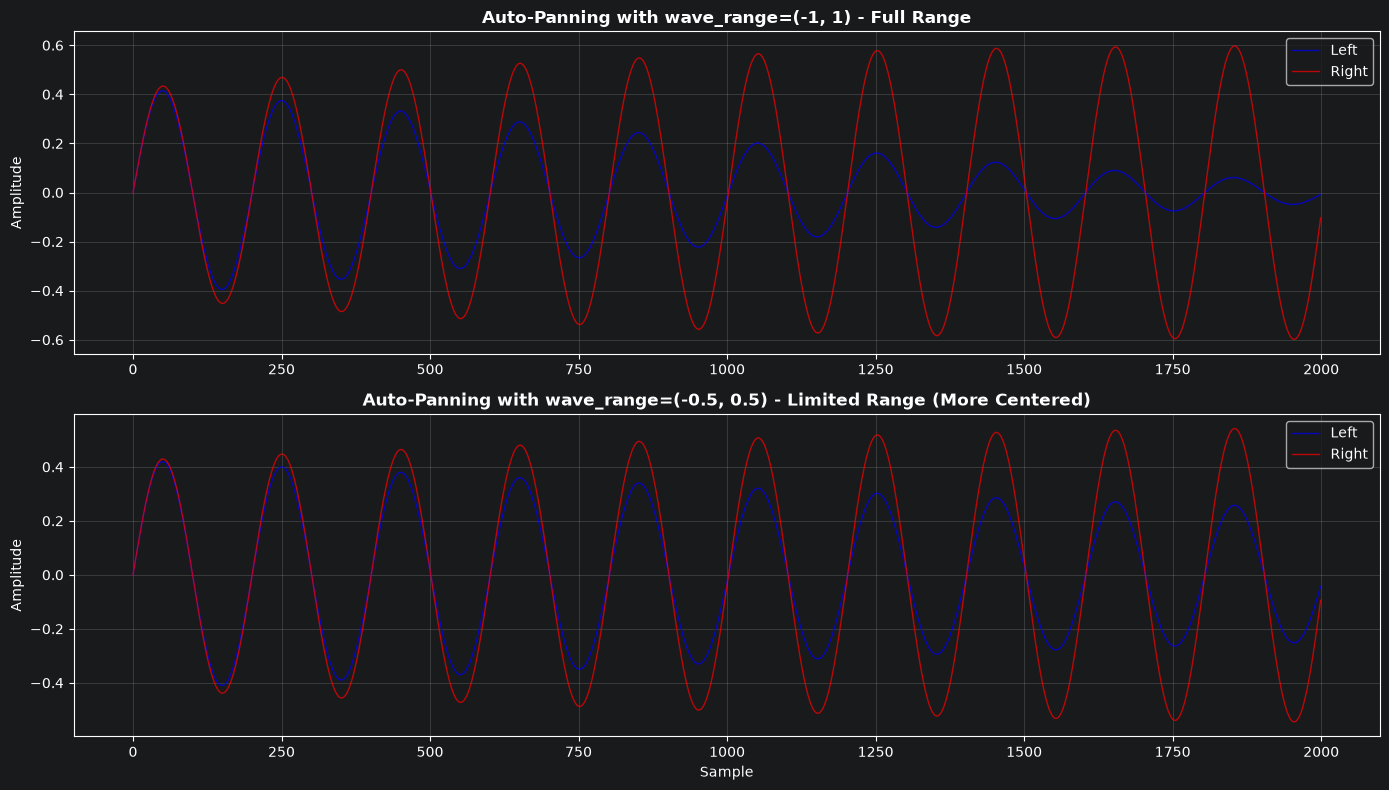


Full Range Panning (wave_range=(-1, 1)):
  Left channel range: [-0.395, 0.415]
  Right channel range: [-0.598, 0.597]
  Channels are different: True

Narrow Range Panning (wave_range=(-0.5, 0.5)):
  Left channel range: [-0.410, 0.419]
  Right channel range: [-0.545, 0.542]
  Channels are different: True


In [4]:
# Create a 220Hz tone with auto-panning
# The LFO oscillates at 4Hz and controls the pan position

# Full range panning (-1 to 1, or hard left to hard right)
lfo_full = SineOscillator(4, amplitude=1, wave_range=(-1, 1))
gen_full = Chain(SineOscillator(220, amplitude=0.6), ModulatedPanner(lfo_full))

# Limited range panning (-0.5 to 0.5, stays more centered)
lfo_narrow = SineOscillator(4, amplitude=1, wave_range=(-0.5, 0.5))
gen_narrow = Chain(SineOscillator(220, amplitude=0.6), ModulatedPanner(lfo_narrow))

# Generate samples
samples_full = gen_full.get_samples(2000)
samples_narrow = gen_narrow.get_samples(2000)

l_full, r_full = np.array(samples_full).T
l_narrow, r_narrow = np.array(samples_narrow).T

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full range panning
axes[0].plot(l_full, "b-", label="Left", alpha=0.7, linewidth=1)
axes[0].plot(r_full, "r-", label="Right", alpha=0.7, linewidth=1)
axes[0].set_title(
    "Auto-Panning with wave_range=(-1, 1) - Full Range", fontsize=12, fontweight="bold"
)
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Narrow range panning
axes[1].plot(l_narrow, "b-", label="Left", alpha=0.7, linewidth=1)
axes[1].plot(r_narrow, "r-", label="Right", alpha=0.7, linewidth=1)
axes[1].set_title(
    "Auto-Panning with wave_range=(-0.5, 0.5) - Limited Range (More Centered)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Sample")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print verification
print("\nFull Range Panning (wave_range=(-1, 1)):")
print(f"  Left channel range: [{l_full.min():.3f}, {l_full.max():.3f}]")
print(f"  Right channel range: [{r_full.min():.3f}, {r_full.max():.3f}]")
print(f"  Channels are different: {not np.allclose(l_full, r_full)}")

print("\nNarrow Range Panning (wave_range=(-0.5, 0.5)):")
print(f"  Left channel range: [{l_narrow.min():.3f}, {l_narrow.max():.3f}]")
print(f"  Right channel range: [{r_narrow.min():.3f}, {r_narrow.max():.3f}]")
print(f"  Channels are different: {not np.allclose(l_narrow, r_narrow)}")

## Example 4: Visualizing the Pan Position Over Time


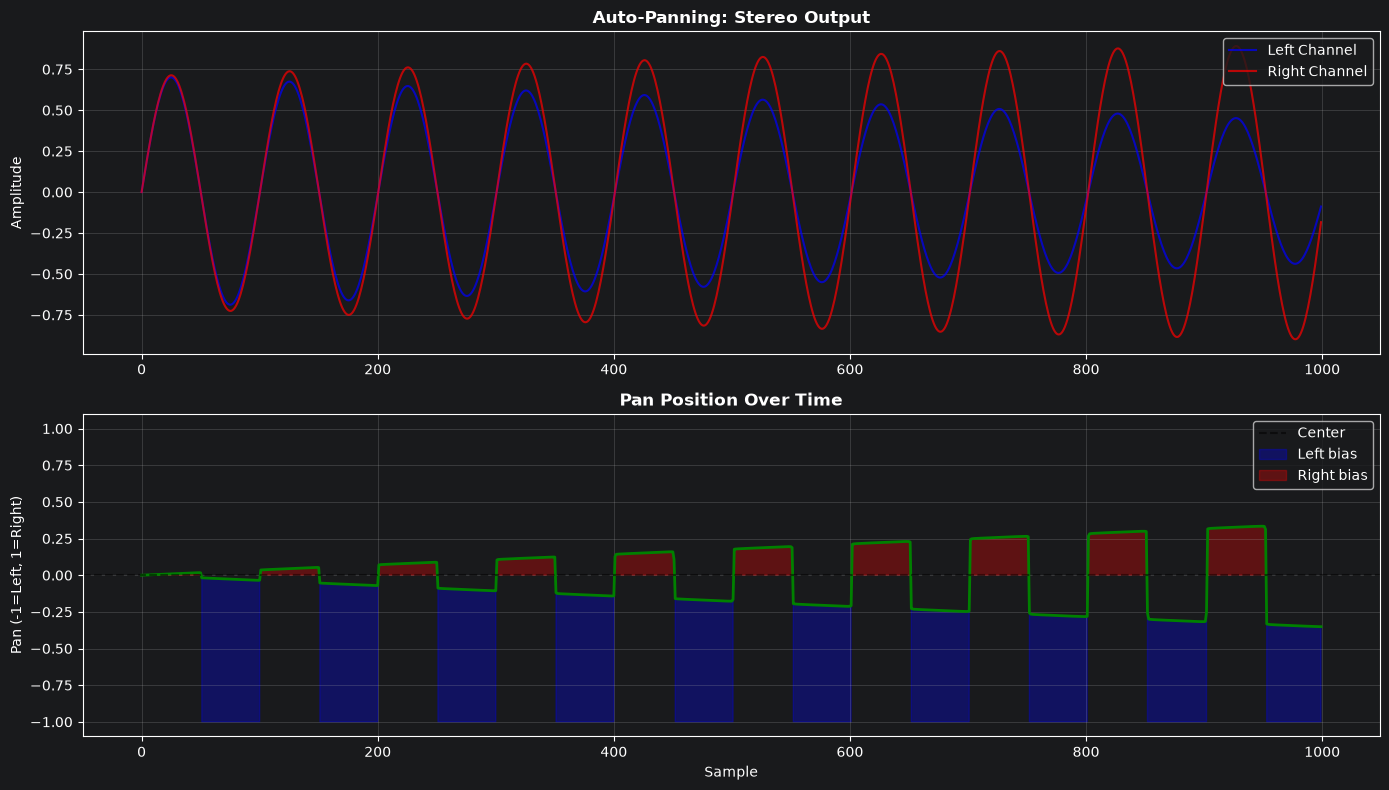


Key Concepts:
  • wave_range controls how far the LFO oscillates
  • wave_range=(-1, 1) creates full left-to-right panning
  • wave_range=(-0.8, 0.8) limits the panning range
  • wave_range=(0, 1) would pan from center to right only
  • The LFO frequency controls how fast the panning moves


In [5]:
# Create a slow auto-panning effect so we can see the pan position change
lfo_slow = SineOscillator(4, amplitude=1.0, wave_range=(-0.8, 0.8))  # 4 Hz oscillation
gen_slow = Chain(SineOscillator(440, amplitude=1), ModulatedPanner(lfo_slow))

# Generate samples
num_samples = 1000
samples = gen_slow.get_samples(num_samples)
left, right = np.array(samples).T

# Calculate pan position from the ratio of left/right channels
# (This is an approximation)
# 0.0001 - Avoid division by zero
pan_indicator = (right - left) / (np.abs(left) + np.abs(right) + 0.001)

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Stereo channels
axes[0].plot(left, "b-", label="Left Channel", alpha=0.7, linewidth=1.5)
axes[0].plot(right, "r-", label="Right Channel", alpha=0.7, linewidth=1.5)
axes[0].set_title("Auto-Panning: Stereo Output", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Pan position indicator
axes[1].plot(pan_indicator, "g-", linewidth=2)
axes[1].axhline(y=0, color="k", linestyle="--", alpha=0.5, label="Center")
axes[1].fill_between(
    range(num_samples),
    -1,
    pan_indicator,
    where=(pan_indicator < 0),
    alpha=0.3,
    color="blue",
    label="Left bias",
)
axes[1].fill_between(
    range(num_samples),
    0,
    pan_indicator,
    where=(pan_indicator > 0),
    alpha=0.3,
    color="red",
    label="Right bias",
)
axes[1].set_title("Pan Position Over Time", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Pan (-1=Left, 1=Right)")
axes[1].set_xlabel("Sample")
axes[1].set_ylim(-1.1, 1.1)
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Concepts:")
print("  • wave_range controls how far the LFO oscillates")
print("  • wave_range=(-1, 1) creates full left-to-right panning")
print("  • wave_range=(-0.8, 0.8) limits the panning range")
print("  • wave_range=(0, 1) would pan from center to right only")
print("  • The LFO frequency controls how fast the panning moves")

## Verification: All Examples Working Correctly


In [6]:
# Let's verify all examples produced the expected

print("=" * 70)
print("VERIFICATION RESULTS")
print("=" * 70)

# Test 1: Static panning positions work
print("\n✅ Example 1 - Static Panning:")
print(f"   Hard left: Right channel ≈ 0? {np.allclose(left_r, 0, atol=0.01)}")
print(f"   Center: Left ≈ Right? {np.allclose(center_l, center_r)}")
print(f"   Hard right: Left channel ≈ 0? {np.allclose(right_l, 0, atol=0.01)}")

# Test 2: wave_range controls output range
print("\n✅ Example 2 - wave_range Parameter:")
print(
    f"   Default range correct: "
    f"{samples_default.min() > -1.1 and samples_default.max() < 1.1}"
)
print(
    f"   Narrow range correct: "
    f"{samples_narrow.min() > -0.6 and samples_narrow.max() < 0.6}"
)
print(
    f"   Shifted range correct: "
    f"{samples_shifted.min() > -0.1 and samples_shifted.max() < 1.1}"
)

# Test 3: Auto-panning creates different channels
print("\n✅ Example 3 - Auto-Panning:")
print(f"   Full range: Channels different? {not np.allclose(l_full, r_full)}")
print(f"   Narrow range: Channels different? {not np.allclose(l_narrow, r_narrow)}")
print("   Both panning correctly!")

# Test 4: Pan position visualization
print("\n✅ Example 4 - Pan Position Visualization:")
print(
    f"   Stereo output generated: "
    f"{len(left) == num_samples and len(right) == num_samples}"
)
print(f"   Channels are different: {not np.allclose(left, right)}")
print(f"   Pan varies over time: {len(set(np.round(pan_indicator, 2))) > 10}")

print("\n" + "=" * 70)
print("🎉 ALL EXAMPLES WORKING AS EXPECTED!")
print("=" * 70)
print("\nThe notebook demonstrates:")
print("  ✓ Static panning at different positions")
print("  ✓ wave_range parameter controlling output values")
print("  ✓ Auto-panning with full and limited ranges")
print("  ✓ Visualization of pan position over time")

VERIFICATION RESULTS

✅ Example 1 - Static Panning:
   Hard left: Right channel ≈ 0? True
   Center: Left ≈ Right? True
   Hard right: Left channel ≈ 0? True

✅ Example 2 - wave_range Parameter:
   Default range correct: True
   Narrow range correct: True
   Shifted range correct: True

✅ Example 3 - Auto-Panning:
   Full range: Channels different? True
   Narrow range: Channels different? True
   Both panning correctly!

✅ Example 4 - Pan Position Visualization:
   Stereo output generated: True
   Channels are different: True
   Pan varies over time: True

🎉 ALL EXAMPLES WORKING AS EXPECTED!

The notebook demonstrates:
  ✓ Static panning at different positions
  ✓ wave_range parameter controlling output values
  ✓ Auto-panning with full and limited ranges
  ✓ Visualization of pan position over time
